# 02. Extention of Edgar's Study

In [4]:
!sudo apt-get update -qq
!sudo apt-get install -y texlive-latex-extra texlive-fonts-recommended dvipng cm-super


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  cm-super-minimal dvisvgm fonts-lato fonts-lmodern fonts-texgyre
  libapache-pom-java libcommons-logging-java libcommons-parent-java
  libfontbox-java libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern pfb2t1c2pfb preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-recommended texlive-pictures texlive-plain-generic tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  libavalon-framework-java libcommons-loggin

In [5]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_abs_deviation
import warnings
from scipy.stats import mannwhitneyu
from scipy.stats import gaussian_kde
from __future__ import annotations
import os, re, math
from typing import Iterable, Set, Dict, Tuple, Sequence, List
from polars import selectors as cs
import polars as pl
from itertools import combinations
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.cm as cm
from scipy.stats import spearmanr
from matplotlib_venn import venn3
from matplotlib.patches import Patch

%config HistoryManager.enabled = False
warnings.filterwarnings('ignore')


In [6]:
# THESIS STYLE FOR PLOT
def apply_thesis_style(use_tex: bool = True,
                       legend_position: str = "upper right",
                       legend_outside: bool = False):
    """
    Applies a uniform style (Matplotlib + Seaborn) consistent with LaTeX
    and defines `place_legend()` to position legends consistently.

    Parameters
    ----------
    use_tex : bool
        If True, enables LaTeX text rendering (requires TeX installed).
    legend_position : str
        DEFAULT position for legends: 'upper right', 'upper left',
        'lower right', 'lower left', 'center', 'best' (also accepts 'top/bottom').
    legend_outside : bool
        If True, the default legend is outside the plot (to the right).
    """

    # --- Normalize default position ---
    def _normalize_pos(pos: str) -> str:
        if not isinstance(pos, str):
            return "upper right"
        key = pos.strip().lower().replace("top", "upper").replace("bottom", "lower")
        mapping = {
            "upper right": "upper right",
            "upper left":  "upper left",
            "lower right": "lower right",
            "lower left":  "lower left",
            "center":      "center",
            "best":        "best",
        }
        return mapping.get(key, "upper right")

    _default_loc = _normalize_pos(legend_position)

    # --- Seaborn theme + rcParams consistent with thesis ---
    sns.set_theme(style="whitegrid", context="notebook")
    mpl.rcParams.update({
        # Typography
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "Latin Modern Roman", "Times New Roman"],
        "mathtext.fontset": "cm",
        "text.usetex": bool(use_tex),

        # Sizes
        "figure.figsize": (6.8, 4.5),
        "font.size": 8.5,          # generic text (plt.text, etc.)
        "axes.labelsize": 10.5,    # axis labels
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9.5,
        "legend.title_fontsize": 9.5,

        # Axes look
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.facecolor": "white",
        "axes.edgecolor": "#D0D0D0",
        "axes.linewidth": 0.8,

        # Legend style (default; can be overridden by place_legend)
        "legend.frameon": True,
        "legend.facecolor": "white",
        "legend.edgecolor": "#D0D0D0",
        "legend.loc": _default_loc,
        "legend.framealpha": 1.0,
        "legend.handlelength": 1.8,
        "legend.handletextpad": 0.6,
        "legend.borderpad": 0.4,
        "legend.borderaxespad": 0.8,
    })

    def place_legend(ax=None,
                     position: str | None = None,
                     outside: bool | None = None,
                     fontsize: float | None = None):
        """
        Places the legend on an axis with consistent thesis style.

        Parameters
        ----------
        ax : matplotlib.axes.Axes, optional
            Axis on which to place the legend (default: current axis).
        position : str | None
            'upper right', 'upper left', 'lower right', 'lower left', 'center', 'best'.
            If None, uses the default position passed to apply_thesis_style().
            Spaces/caps tolerated; 'top/bottom' mapped to 'upper/lower'.
        outside : bool | None
            If True, places the legend outside the plot (to the right).
            If None, uses the default value passed to apply_thesis_style().
        fontsize : float | None
            To change the legend font size only in this plot.
        """

        if ax is None:
            ax = plt.gca()

        # Normalize requested position or use global default
        loc_val = _default_loc
        if isinstance(position, str):
            key = position.strip().lower().replace("top", "upper").replace("bottom", "lower")
            loc_map = {
                "upper right": "upper right",
                "upper left":  "upper left",
                "lower right": "lower right",
                "lower left":  "lower left",
                "center":      "center",
                "best":        "best",
            }
            loc_val = loc_map.get(key, _default_loc)

        # outside: if None, inherit from default; otherwise use override
        outside = (legend_outside if outside is None else bool(outside))

        # Build kwargs consistent with rcParams
        legend_kwargs = dict(
            loc=loc_val,
            frameon=True,
            facecolor="white",
            edgecolor=mpl.rcParams["legend.edgecolor"],
            framealpha=1.0,
            fontsize=mpl.rcParams["legend.fontsize"] if fontsize is None else fontsize,
            handlelength=1.8,
            handletextpad=0.6,
            borderpad=0.4,
            fancybox=False,
        )

        if outside:
            legend_kwargs.update({
                "bbox_to_anchor": (1.02, 1.0),
                "borderaxespad": 0.0,
            })

        leg = ax.legend(**legend_kwargs)
        if leg is not None:
            leg.get_frame().set_linewidth(0.8)
            leg.get_frame().set_edgecolor(mpl.rcParams["legend.edgecolor"])
            leg.get_frame().set_facecolor("white")
        return ax

    # Export the helper to the global notebook/script namespace
    globals()["place_legend"] = place_legend
    

In [1]:
############################################################
# BREAST NON-VARIABLE CPGs (EDGAR-STYLE) — CROSS-DATASET
# DATASETS: GSE69914 (450K), GSE225845 (EPIC), GSE287331 (EPIC)
# 
# STEPS:
#  A) Define input parquet paths (beta matrices with id_tissue + label)
#  B) Filter Normal samples (label == 0) in each dataset
#  C) Find CpG intersection across all three datasets
#  D) Build a combined "Breast Normal, common CpGs" beta matrix
#  E) Compute r_beta = P90 - P10 across all breast-normal samples
#  F) Apply r_beta < 0.05 → Breast non-variable CpG list
#  G) (Optional) Intersect with Edgar's lists
############################################################

import polars as pl

# ============================================================
# STEP A — DEFINE INPUT PATHS AND GLOBAL CONSTANTS
# ============================================================

# IMPORTANT:
# These should point to BETA matrices (not M-values),
# with at least: [id_tissue, label, CpG columns...]
# and AFTER your technical/missingness filtering BUT BEFORE BMIQ.

print("========== STEP A ==========")

PATH_BETA_69914   = "/kaggle/input/gse69914-parquet/GSE69914.parquet"
PATH_BETA_225845  = "/kaggle/input/gse225845-parquet/GSE225845.parquet"
PATH_BETA_287331  = "/kaggle/input/3-gse287331-parquet/GSE287331_clean_imputed.parquet"

# Output paths
OUT_COMMON_CPGS_CSV       = "/kaggle/working/breast_common_cpgs_3datasets.csv"
OUT_NORMAL_69914_PARQUET  = "/kaggle/working/GSE69914_breast_normal_common.parquet"
OUT_NORMAL_225845_PARQUET = "/kaggle/working/GSE225845_breast_normal_common.parquet"
OUT_NORMAL_287331_PARQUET = "/kaggle/working/GSE287331_breast_normal_common.parquet"
OUT_BREAST_NORMAL_PARQUET = "/kaggle/working/BREAST_normal_common_cpgs_all.parquet"
OUT_RBETA_PARQUET         = "/kaggle/working/BREAST_r_beta_common_cpgs.parquet"
OUT_INVARIANTS_PARQUET    = "/kaggle/working/BREAST_invariants_rbeta_0_05.parquet"
OUT_INVARIANTS_CSV        = "/kaggle/working/BREAST_invariants_rbeta_0_05.csv"

# Column names
ID_COL    = "id_tissue"
LABEL_COL = "label"
NORMAL_LABEL = 0  # adjust if needed

# ============================================================
# STEP B — FILTER NORMAL SAMPLES (label == 0) — SCHEMA ONLY
# ============================================================
print("========== STEP B ==========")
def get_cpg_cols_from_schema(schema: dict) -> list[str]:
    """
    Return CpG column names from a Polars schema: all columns except id_tissue, label.
    """
    return [c for c in schema.keys() if c not in (ID_COL, LABEL_COL)]

# Get schemas without loading full data
schema_69914  = pl.scan_parquet(PATH_BETA_69914).schema
schema_225845 = pl.scan_parquet(PATH_BETA_225845).schema
schema_287331 = pl.scan_parquet(PATH_BETA_287331).schema

cpg_69914  = set(get_cpg_cols_from_schema(schema_69914))
cpg_225845 = set(get_cpg_cols_from_schema(schema_225845))
cpg_287331 = set(get_cpg_cols_from_schema(schema_287331))

# ============================================================
# STEP C — FIND COMMON CpGs ACROSS ALL THREE DATASETS
# ============================================================
print("========== STEP C ==========")
common_cpgs = sorted(list(cpg_69914 & cpg_225845 & cpg_287331))
print(f"Number of common CpGs across all three datasets: {len(common_cpgs):,}")

# Save for reproducibility
pl.DataFrame({"CpG_ID": common_cpgs}).write_csv(OUT_COMMON_CPGS_CSV)

# Columns to keep in each dataset
COLUMNS_TO_KEEP = [ID_COL, LABEL_COL] + common_cpgs

# ============================================================
# STEP D — BUILD BREAST-NORMAL BETA MATRIX (COMMON CpGs)
# ============================================================
print("========== STEP D ==========")
def save_normal_subset_common_cpgs(
    in_parquet: str,
    out_parquet: str,
    label_col: str = LABEL_COL,
    normal_label: int = NORMAL_LABEL,
    cols_to_keep: list[str] = None,
):
    """
    Read a beta matrix in streaming, filter Normal samples, select only common CpGs,
    and write to a new parquet file, WITHOUT loading entire dataset in RAM.
    """
    if cols_to_keep is None:
        raise ValueError("cols_to_keep must be provided.")

    lf = (
        pl.scan_parquet(in_parquet)
        .filter(pl.col(label_col) == normal_label)
        .select(cols_to_keep)
    )

    # Streaming write: no full collect in memory
    lf.sink_parquet(out_parquet)
    print(f"Saved Normal subset with common CpGs to: {out_parquet}")

# Apply to each dataset
save_normal_subset_common_cpgs(
    PATH_BETA_69914,
    OUT_NORMAL_69914_PARQUET,
    cols_to_keep=COLUMNS_TO_KEEP,
)

save_normal_subset_common_cpgs(
    PATH_BETA_225845,
    OUT_NORMAL_225845_PARQUET,
    cols_to_keep=COLUMNS_TO_KEEP,
)

save_normal_subset_common_cpgs(
    PATH_BETA_287331,
    OUT_NORMAL_287331_PARQUET,
    cols_to_keep=COLUMNS_TO_KEEP,
)

# Concatenate all Normal samples into a single breast-normal matrix
lf_69914  = pl.scan_parquet(OUT_NORMAL_69914_PARQUET)
lf_225845 = pl.scan_parquet(OUT_NORMAL_225845_PARQUET)
lf_287331 = pl.scan_parquet(OUT_NORMAL_287331_PARQUET)

lf_breast_normal = pl.concat([lf_69914, lf_225845, lf_287331], how="vertical")

# Streaming write to final combined file
lf_breast_normal.sink_parquet(OUT_BREAST_NORMAL_PARQUET)
print(f"Combined breast-normal matrix saved to: {OUT_BREAST_NORMAL_PARQUET}")

# ============================================================
# STEP E — COMPUTE r_beta = P90 - P10 ACROSS ALL BREAST-NORMAL SAMPLES
# ============================================================
print("========== STEP E ==========")
# Now we can safely load this one dataset in RAM (size ~1–2 GB)
breast_df = pl.read_parquet(OUT_BREAST_NORMAL_PARQUET)
print("BREAST-normal matrix shape:", breast_df.shape)

# CpG columns are all except id_tissue and label
cpg_cols_breast = [c for c in breast_df.columns if c not in (ID_COL, LABEL_COL)]
print(f"Number of CpG columns in breast-normal matrix: {len(cpg_cols_breast):,}")

# Compute P10 and P90 per CpG
q10_df = breast_df.select(pl.col(cpg_cols_breast).quantile(0.10))
q90_df = breast_df.select(pl.col(cpg_cols_breast).quantile(0.90))

# r_beta = P90 - P10 -> still a single-row DataFrame
r_beta_df = q90_df - q10_df

# Transpose to long format: one row per CpG
r_beta_long = r_beta_df.transpose(
    include_header=True,
    header_name="CpG_ID",
    column_names=["r_beta"],
)

print("r_beta_long head:")
print(r_beta_long.head())

# Save r_beta table
r_beta_long.write_parquet(OUT_RBETA_PARQUET)
print(f"Saved r_beta values to: {OUT_RBETA_PARQUET}")

# ============================================================
# STEP F — APPLY THRESHOLD r_beta < 0.05 TO DEFINE BREAST INVARIANTS
# ============================================================
print("========== STEP F ==========")
THRESHOLD = 0.05

invariants_df = r_beta_long.filter(pl.col("r_beta") < THRESHOLD)
print(f"Number of non-variable CpGs (r_beta < {THRESHOLD}): {invariants_df.height:,}")

# Save invariants list
invariants_df.write_parquet(OUT_INVARIANTS_PARQUET)
invariants_df.write_csv(OUT_INVARIANTS_CSV)
print(f"Saved breast invariant CpGs to: {OUT_INVARIANTS_PARQUET}")
print(f"and CSV: {OUT_INVARIANTS_CSV}")


========== STEP A ==========
========== STEP B ==========


/tmp/ipykernel_47/2918889720.py:58: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  schema_69914  = pl.scan_parquet(PATH_BETA_69914).schema
/tmp/ipykernel_47/2918889720.py:59: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  schema_225845 = pl.scan_parquet(PATH_BETA_225845).schema
/tmp/ipykernel_47/2918889720.py:60: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  schema_287331 = pl.scan_parquet(PATH_BETA_287331).schema


========== STEP C ==========
Number of common CpGs across all three datasets: 326,330
========== STEP D ==========
Saved Normal subset with common CpGs to: /kaggle/working/GSE69914_breast_normal_common.parquet
Saved Normal subset with common CpGs to: /kaggle/working/GSE225845_breast_normal_common.parquet
Saved Normal subset with common CpGs to: /kaggle/working/GSE287331_breast_normal_common.parquet
Combined breast-normal matrix saved to: /kaggle/working/BREAST_normal_common_cpgs_all.parquet
========== STEP E ==========
BREAST-normal matrix shape: (345, 326332)
Number of CpG columns in breast-normal matrix: 326,330
r_beta_long head:
shape: (5, 2)
┌────────────┬──────────┐
│ CpG_ID     ┆ r_beta   │
│ ---        ┆ ---      │
│ str        ┆ f32      │
╞════════════╪══════════╡
│ cg00000109 ┆ 0.208174 │
│ cg00000165 ┆ 0.161113 │
│ cg00000236 ┆ 0.12481  │
│ cg00000363 ┆ 0.087583 │
│ cg00000622 ┆ 0.01511  │
└────────────┴──────────┘
Saved r_beta values to: /kaggle/working/BREAST_r_beta_common

In [3]:
# ============================================================
# STEP G — INTERSECTION WITH EDGAR NON-VARIABLE CpG SETS
# ============================================================
print("========== STEP G — Breast invariants vs Edgar ==========")

# Input paths (update if needed)
PATH_EDGAR_BLOOD     = "/kaggle/input/invariant-blood-cpgs-csv/Invariant_Blood_CpGs.csv"
PATH_EDGAR_BUCCAL    = "/kaggle/input/invariant-buccal-cpgs-csv/Invariant_Buccal_CpGs.csv"
PATH_EDGAR_PLACENTA  = "/kaggle/input/invariant-placenta-cpgs-csv/Invariant_Placenta_CpGs.csv"

# Output path for the universal Edgar set
OUT_EDGAR_UNIVERSAL_CSV = "/kaggle/working/Edgar_universal_42315_cpgs_from_sets.csv"

# 1) Load Edgar invariant CpG lists (assumes column 'CpG_ID')
edgar_blood    = pl.read_csv(PATH_EDGAR_BLOOD)["CpG"].to_list()
edgar_buccal   = pl.read_csv(PATH_EDGAR_BUCCAL)["CpG"].to_list()
edgar_placenta = pl.read_csv(PATH_EDGAR_PLACENTA)["CpG"].to_list()

blood_set    = set(edgar_blood)
buccal_set   = set(edgar_buccal)
placenta_set = set(edgar_placenta)

print(f"Edgar blood invariants:    {len(blood_set):,}")
print(f"Edgar buccal invariants:   {len(buccal_set):,}")
print(f"Edgar placenta invariants: {len(placenta_set):,}")

# 2) Build Edgar UNIVERSAL set = Blood ∩ Buccal ∩ Placenta
edgar_universal_set = blood_set & buccal_set & placenta_set
print(f"Edgar UNIVERSAL invariants (Blood ∩ Buccal ∩ Placenta): {len(edgar_universal_set):,}")

# Save universal list for reproducibility
pl.DataFrame({"CpG_ID": sorted(edgar_universal_set)}).write_csv(OUT_EDGAR_UNIVERSAL_CSV)
print(f"Saved Edgar universal invariant list to: {OUT_EDGAR_UNIVERSAL_CSV}")

# 3) Load breast invariants (computed previously in STEP F)
breast_inv_set = set(invariants_df["CpG_ID"].to_list())
print(f"Breast invariants (r_beta < 0.05): {len(breast_inv_set):,}")

# 4) Compute pairwise overlaps with Edgar invariant sets
overlap_blood    = len(breast_inv_set & blood_set)
overlap_buccal   = len(breast_inv_set & buccal_set)
overlap_placenta = len(breast_inv_set & placenta_set)

# 5) Overlap with Edgar UNIVERSAL set (4-way intersection)
overlap_universal = len(breast_inv_set & edgar_universal_set)

print("\nBreast invariants vs Edgar non-variable CpG sets:")
print(f"  Overlap with blood invariants:              {overlap_blood:,}")
print(f"  Overlap with buccal invariants:             {overlap_buccal:,}")
print(f"  Overlap with placenta invariants:           {overlap_placenta:,}")
print(f"  Overlap with UNIVERSAL (Blood∩Buccal∩Plac): {overlap_universal:,}")

# Full 4-way intersection list (Breast + all Edgar tissues)
breast_and_edgar_univ = breast_inv_set & edgar_universal_set
print(f"\n4-way intersection (Breast ∩ Blood ∩ Buccal ∩ Placenta): {len(breast_and_edgar_univ):,}")


========== STEP G — Breast invariants vs Edgar ==========
Edgar blood invariants:    114,204
Edgar buccal invariants:   120,009
Edgar placenta invariants: 101,367
Edgar UNIVERSAL invariants (Blood ∩ Buccal ∩ Placenta): 42,315
Saved Edgar universal invariant list to: /kaggle/working/Edgar_universal_42315_cpgs_from_sets.csv
Breast invariants (r_beta < 0.05): 85,341

Breast invariants vs Edgar non-variable CpG sets:
  Overlap with blood invariants:              70,703
  Overlap with buccal invariants:             57,001
  Overlap with placenta invariants:           42,967
  Overlap with UNIVERSAL (Blood∩Buccal∩Plac): 29,870

4-way intersection (Breast ∩ Blood ∩ Buccal ∩ Placenta): 29,870


Installing venn package...
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for venn: filename=venn-0.1.3-py3-none-any.whl size=19701 sha256=963ce126780d9b71c218abaa3b266d0bf4e125d5721944ee52ad8bbaea049eca
  Stored in directory: /root/.cache/pip/wheels/b8/2a/b1/a1ff9ba87eb919daed348de8c17b00024dfef34b35e7002e6c
Successfully built venn
Blood invariants:    114,204
Buccal invariants:   120,009
Placenta invariants: 101,367
Breast invariants:   85,341

4-way intersection (Blood ∩ Buccal ∩ Placenta ∩ Breast): 29,870


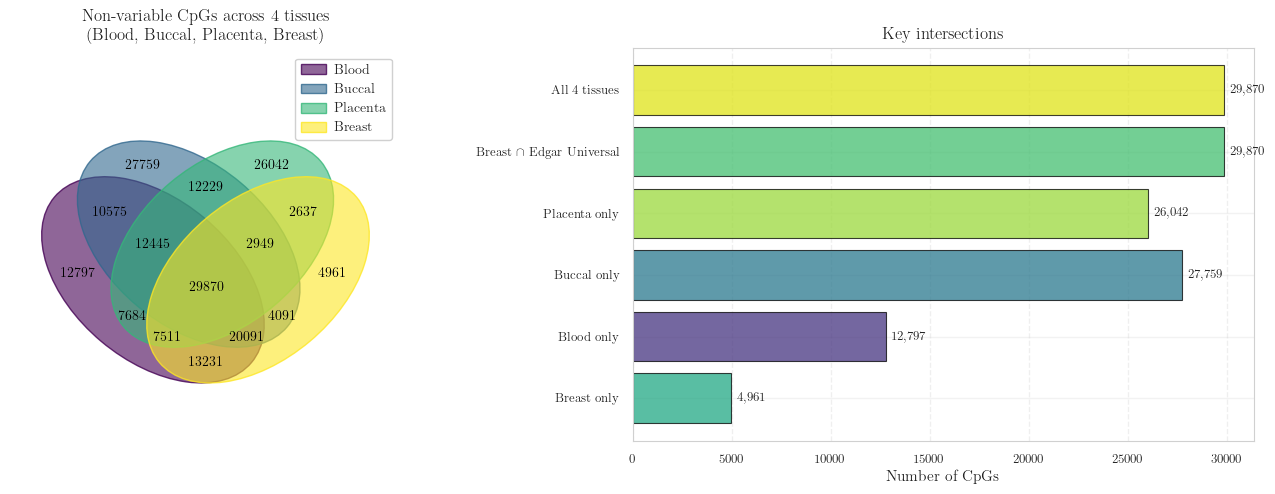


SUMMARY OF INVARIANT CpGs
Blood:                                    114,204
Buccal:                                   120,009
Placenta:                                 101,367
Breast:                                   85,341

Edgar Universal (Blood∩Buccal∩Placenta):  42,315
Breast ∩ Edgar Universal:                 29,870

4-WAY INTERSECTION (All tissues):         29,870

Saved 4-tissue universal invariants to: Universal_4tissues_invariants.csv


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Prova prima con matplotlib_venn estesa
try:
    from matplotlib_venn import venn3_circles
    # Proviamo a importare venn da pypi
    from venn import venn
    USE_VENN_PACKAGE = True
except ImportError:
    USE_VENN_PACKAGE = False
    print("Installing venn package...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'venn'])
    from venn import venn
    USE_VENN_PACKAGE = True

# ============================================================
# LOAD ALL 4 TISSUE INVARIANT LISTS
# ============================================================

# Load Blood / Buccal / Placenta / Breast
blood = set(pd.read_csv(
    "/kaggle/input/invariant-blood-cpgs-csv/Invariant_Blood_CpGs.csv"
)["CpG"])
buccal = set(pd.read_csv(
    "/kaggle/input/invariant-buccal-cpgs-csv/Invariant_Buccal_CpGs.csv"
)["CpG"])
placenta = set(pd.read_csv(
    "/kaggle/input/invariant-placenta-cpgs-csv/Invariant_Placenta_CpGs.csv"
)["CpG"])

# Load Breast invariants (from the previous code)
breast = set(invariants_df["CpG_ID"].to_list())

print(f"Blood invariants:    {len(blood):,}")
print(f"Buccal invariants:   {len(buccal):,}")
print(f"Placenta invariants: {len(placenta):,}")
print(f"Breast invariants:   {len(breast):,}")

# Universal invariants (all 4 tissues)
U_all = blood & buccal & placenta & breast
print(f"\n4-way intersection (Blood ∩ Buccal ∩ Placenta ∩ Breast): {len(U_all):,}")

# ============================================================
# VENN DIAGRAM WITH 4 TISSUES
# ============================================================

if "apply_thesis_style" in globals():
    apply_thesis_style(use_tex=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# LEFT PANEL: 4-way Venn diagram
venn_dict = {
    'Blood': blood,
    'Buccal': buccal,
    'Placenta': placenta,
    'Breast': breast,
}

venn(venn_dict, ax=ax1, cmap='viridis', alpha=0.6, fontsize=10)
ax1.set_title("Non-variable CpGs across 4 tissues\n(Blood, Buccal, Placenta, Breast)", 
              fontsize=12)

# RIGHT PANEL: Key intersections bar chart
c_blood  = plt.cm.viridis(0.15)
c_buccal = plt.cm.viridis(0.40)
c_breast = plt.cm.viridis(0.60)
c_plac   = plt.cm.viridis(0.85)

U_edgar = blood & buccal & placenta

intersections = {
    'Breast only': len(breast - blood - buccal - placenta),
    'Blood only': len(blood - buccal - placenta - breast),
    'Buccal only': len(buccal - blood - placenta - breast),
    'Placenta only': len(placenta - blood - buccal - breast),
    r'Breast $\cap$ Edgar Universal': len(breast & U_edgar),
    'All 4 tissues': len(U_all),
}

colors_map = {
    'Breast only': c_breast,
    'Blood only': c_blood,
    'Buccal only': c_buccal,
    'Placenta only': c_plac,
    r'Breast $\cap$ Edgar Universal': plt.cm.viridis(0.70),
    'All 4 tissues': plt.cm.viridis(0.95),
}

labels = list(intersections.keys())
values = list(intersections.values())
colors = [colors_map[l] for l in labels]

bars = ax2.barh(labels, values, color=colors, alpha=0.75, edgecolor='black', linewidth=0.8)
ax2.set_xlabel('Number of CpGs', fontsize=11)
ax2.set_title('Key intersections', fontsize=12)
ax2.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, values)):
    ax2.text(val + max(values)*0.01, i, f'{val:,}', 
             va='center', fontsize=9)

fig.tight_layout()
fig.savefig("venn_4tissues_invariants.pdf", bbox_inches="tight")
plt.show()

# ============================================================
# SUMMARY TABLE
# ============================================================
print("\n" + "="*60)
print("SUMMARY OF INVARIANT CpGs")
print("="*60)
print(f"Blood:                                    {len(blood):,}")
print(f"Buccal:                                   {len(buccal):,}")
print(f"Placenta:                                 {len(placenta):,}")
print(f"Breast:                                   {len(breast):,}")
print(f"\nEdgar Universal (Blood∩Buccal∩Placenta):  {len(U_edgar):,}")
print(f"Breast ∩ Edgar Universal:                 {len(breast & U_edgar):,}")
print(f"\n4-WAY INTERSECTION (All tissues):         {len(U_all):,}")
print("="*60)

# Save the 4-way universal list
import polars as pl
pl.DataFrame({"CpG_ID": sorted(U_all)}).write_csv(
    "/kaggle/working/Universal_4tissues_invariants.csv"
)
print("\nSaved 4-tissue universal invariants to: Universal_4tissues_invariants.csv")

Breast-normal combined matrix (with dataset column): (345, 326333)
Number of CpGs used for correlation: 326,330
Correlation matrix shape: (345, 345)
Saved:
  - Heatmap:              /kaggle/working/BREAST_01_sample_correlation_heatmap.pdf
  - Mean correlation:     /kaggle/working/BREAST_02_mean_sample_correlation.pdf
  - Combined figure:      /kaggle/working/BREAST_sample_correlation_EDGAR_style.pdf


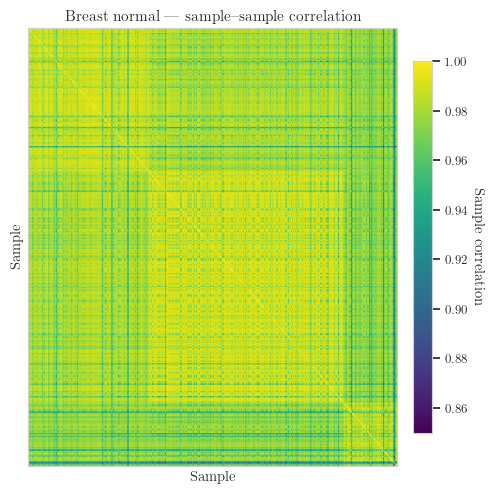

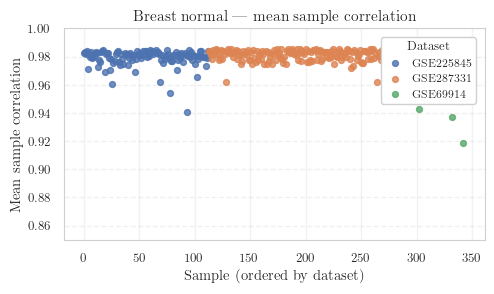

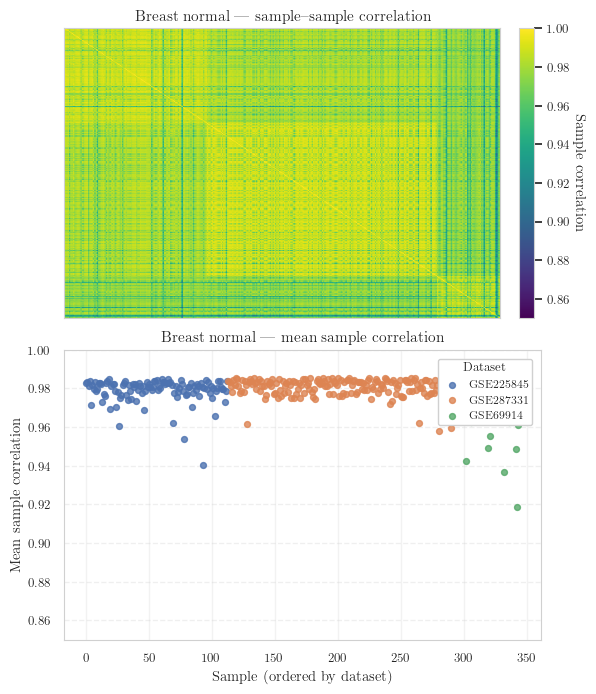

In [13]:
############################################################
# BREAST NORMAL — SAMPLE–SAMPLE CORRELATION (EDGAR-STYLE)
# Panels:
#   a) Sample–sample correlation heatmap + dataset side colors
#   b) Mean sample correlation per sample (colored by dataset)
############################################################

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CONFIG
# ============================================================
PATH_NORMAL_69914   = "/kaggle/working/GSE69914_breast_normal_common.parquet"
PATH_NORMAL_225845  = "/kaggle/working/GSE225845_breast_normal_common.parquet"
PATH_NORMAL_287331  = "/kaggle/working/GSE287331_breast_normal_common.parquet"

OUT_HEATMAP_PDF     = "/kaggle/working/BREAST_01_sample_correlation_heatmap.pdf"
OUT_MEANCORR_PDF    = "/kaggle/working/BREAST_02_mean_sample_correlation.pdf"
OUT_COMBINED_PDF    = "/kaggle/working/BREAST_sample_correlation_EDGAR_style.pdf"

ID_COL    = "id_tissue"
LABEL_COL = "label"

# Optional: apply your thesis style if available
if "apply_thesis_style" in globals():
    apply_thesis_style(use_tex=True)

# ============================================================
# 1) LOAD BREAST-NORMAL SAMPLES FROM EACH DATASET
#    AND ADD A DATASET IDENTIFIER COLUMN
# ============================================================
def load_with_dataset(path: str, dataset_name: str) -> pl.DataFrame:
    df = pl.read_parquet(path)
    df = df.with_columns(
        pl.lit(dataset_name).alias("dataset")
    )
    return df

df_69914  = load_with_dataset(PATH_NORMAL_69914,  "GSE69914")
df_225845 = load_with_dataset(PATH_NORMAL_225845, "GSE225845")
df_287331 = load_with_dataset(PATH_NORMAL_287331, "GSE287331")

# Concatenate vertically: all breast-normal samples in one matrix
df_breast = pl.concat([df_69914, df_225845, df_287331], how="vertical")

print("Breast-normal combined matrix (with dataset column):", df_breast.shape)

# ============================================================
# 2) EXTRACT CpG MATRIX AND SAMPLE METADATA
# ============================================================
cpg_cols = [c for c in df_breast.columns if c not in (ID_COL, LABEL_COL, "dataset")]
print(f"Number of CpGs used for correlation: {len(cpg_cols):,}")

# Convert CpG matrix to pandas (samples x CpGs)
X = df_breast.select(cpg_cols).to_pandas()
sample_ids = df_breast[ID_COL].to_list()
dataset_labels = df_breast["dataset"].to_list()

# ============================================================
# 3) SAMPLE–SAMPLE CORRELATION MATRIX (PANEL a)
# ============================================================
# Pearson correlation across samples
# corr[i,j] = corr(sample_i, sample_j)
corr_matrix = np.corrcoef(X.values)  # shape: (n_samples, n_samples)

print("Correlation matrix shape:", corr_matrix.shape)

# Order samples by dataset (so blocks appear, like in Edgar)
order_idx = np.argsort(dataset_labels)
corr_ord = corr_matrix[order_idx][:, order_idx]

sample_ids_ord    = [sample_ids[i] for i in order_idx]
dataset_labels_ord = [dataset_labels[i] for i in order_idx]

# Map dataset to a color (for the side bar)
palette = {
    "GSE69914": "#440154",   # dark purple
    "GSE225845": "#21918c",  # teal
    "GSE287331": "#fde725",  # yellow
}
row_colors = [palette[d] for d in dataset_labels_ord]

# ------------------------------------------------------------
# HEATMAP (panel a)
# ------------------------------------------------------------
# Use seaborn clustermap-like style but without clustering,
# just displaying the correlation matrix ordered by dataset.
fig_a, ax_a = plt.subplots(figsize=(5, 5))

im = ax_a.imshow(corr_ord, vmin=0.85, vmax=1.0, cmap="viridis", aspect="auto")
ax_a.set_title("Breast normal — sample–sample correlation", fontsize=11)
ax_a.set_xlabel("Sample")
ax_a.set_ylabel("Sample")

# Optional: remove tick labels for a cleaner Edgar-style look
ax_a.set_xticks([])
ax_a.set_yticks([])

# Color bar
cbar = fig_a.colorbar(im, ax=ax_a, fraction=0.046, pad=0.04)
cbar.set_label("Sample correlation", rotation=270, labelpad=12)

fig_a.tight_layout()
fig_a.savefig(OUT_HEATMAP_PDF, bbox_inches="tight")

# ============================================================
# 4) MEAN SAMPLE CORRELATION PER SAMPLE (PANEL b)
# ============================================================
mean_corr = corr_matrix.mean(axis=1)  # average across all other samples

# Reorder according to the same index used for the heatmap
mean_corr_ord = mean_corr[order_idx]

# Build a pandas DataFrame for plotting
df_mean = pd.DataFrame({
    "sample_id": sample_ids_ord,
    "dataset": dataset_labels_ord,
    "mean_corr": mean_corr_ord,
    "index": np.arange(len(sample_ids_ord))  # x-axis ordering
})

# ------------------------------------------------------------
# SCATTER PLOT (panel b)
# ------------------------------------------------------------
fig_b, ax_b = plt.subplots(figsize=(5, 3))

for ds, group in df_mean.groupby("dataset"):
    ax_b.scatter(
        group["index"],
        group["mean_corr"],
        s=18,
        label=ds,
        alpha=0.8
    )

ax_b.set_xlabel("Sample (ordered by dataset)")
ax_b.set_ylabel("Mean sample correlation")
ax_b.set_ylim(0.85, 1.0)
ax_b.set_title("Breast normal — mean sample correlation", fontsize=11)
ax_b.legend(title="Dataset", fontsize=8, title_fontsize=9)
ax_b.grid(axis="y", linestyle="--", alpha=0.3)

fig_b.tight_layout()
fig_b.savefig(OUT_MEANCORR_PDF, bbox_inches="tight")

# ============================================================
# 5) OPTIONAL: COMBINED FIGURE (a + b) IN A SINGLE PDF
# ============================================================
fig_comb, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 7))

# Panel a — heatmap
im2 = ax1.imshow(corr_ord, vmin=0.85, vmax=1.0, cmap="viridis", aspect="auto")
ax1.set_title("Breast normal — sample–sample correlation", fontsize=11)
ax1.set_xticks([])
ax1.set_yticks([])
cbar2 = fig_comb.colorbar(im2, ax=ax1, fraction=0.046, pad=0.04)
cbar2.set_label("Sample correlation", rotation=270, labelpad=12)

# Panel b — mean correlation
for ds, group in df_mean.groupby("dataset"):
    ax2.scatter(
        group["index"],
        group["mean_corr"],
        s=18,
        label=ds,
        alpha=0.8
    )

ax2.set_xlabel("Sample (ordered by dataset)")
ax2.set_ylabel("Mean sample correlation")
ax2.set_ylim(0.85, 1.0)
ax2.set_title("Breast normal — mean sample correlation", fontsize=11)
ax2.legend(title="Dataset", fontsize=8, title_fontsize=9)
ax2.grid(axis="y", linestyle="--", alpha=0.3)

fig_comb.tight_layout()
fig_comb.savefig(OUT_COMBINED_PDF, bbox_inches="tight")

print("Saved:")
print("  - Heatmap:             ", OUT_HEATMAP_PDF)
print("  - Mean correlation:    ", OUT_MEANCORR_PDF)
print("  - Combined figure:     ", OUT_COMBINED_PDF)


Breast-normal combined: (345, 326333)


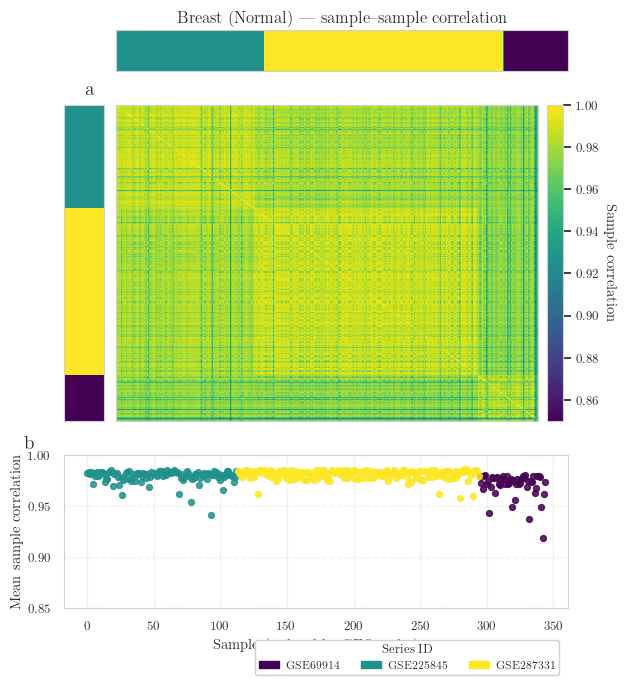

Saved EDGAR-style QC figure to: /kaggle/working/BREAST_QC_sample_correlation_EDGAR_style.pdf


In [14]:
############################################################
# BREAST NORMAL — EDGAR-LIKE QC FIGURE
# One column:
#   a) sample–sample correlation heatmap + side bars (dataset)
#   b) mean sample correlation per sample (colored by dataset)
#   c) legend with GEO series IDs (GSE69914, GSE225845, GSE287331)
############################################################

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# ========= PATHS (adjust if needed) =========
PATH_NORMAL_69914   = "/kaggle/working/GSE69914_breast_normal_common.parquet"
PATH_NORMAL_225845  = "/kaggle/working/GSE225845_breast_normal_common.parquet"
PATH_NORMAL_287331  = "/kaggle/working/GSE287331_breast_normal_common.parquet"

OUT_FIG_PDF = "/kaggle/working/BREAST_QC_sample_correlation_EDGAR_style.pdf"

ID_COL    = "id_tissue"
LABEL_COL = "label"

# Optional: apply your thesis style
if "apply_thesis_style" in globals():
    apply_thesis_style(use_tex=True)

# ========= 1) LOAD DATA + ADD DATASET LABEL =========
def load_with_dataset(path: str, dataset_name: str) -> pl.DataFrame:
    df = pl.read_parquet(path)
    return df.with_columns(pl.lit(dataset_name).alias("dataset"))

df_69914  = load_with_dataset(PATH_NORMAL_69914,  "GSE69914")
df_225845 = load_with_dataset(PATH_NORMAL_225845, "GSE225845")
df_287331 = load_with_dataset(PATH_NORMAL_287331, "GSE287331")

df_breast = pl.concat([df_69914, df_225845, df_287331], how="vertical")
print("Breast-normal combined:", df_breast.shape)

# ========= 2) EXTRACT CpG MATRIX AND METADATA =========
cpg_cols = [c for c in df_breast.columns if c not in (ID_COL, LABEL_COL, "dataset")]
X = df_breast.select(cpg_cols).to_pandas().values      # samples x CpGs
sample_ids      = df_breast[ID_COL].to_list()
dataset_labels  = df_breast["dataset"].to_list()

n_samples = len(sample_ids)

# ========= 3) SAMPLE–SAMPLE CORRELATION =========
corr_matrix = np.corrcoef(X)   # (n_samples, n_samples)

# Order samples by dataset (blocks in the heatmap)
order_idx = np.argsort(dataset_labels)
corr_ord  = corr_matrix[order_idx][:, order_idx]
sample_ids_ord     = [sample_ids[i] for i in order_idx]
dataset_labels_ord = [dataset_labels[i] for i in order_idx]

# Mean sample correlation (panel b)
mean_corr     = corr_matrix.mean(axis=1)
mean_corr_ord = mean_corr[order_idx]
x_idx         = np.arange(n_samples)

# ========= 4) COLORS FOR DATASETS =========
# 3 fixed colors for the three GEO series
dataset_order = ["GSE69914", "GSE225845", "GSE287331"]
dataset_colors = {
    "GSE69914": "#440154",  # dark purple
    "GSE225845": "#21918c", # teal
    "GSE287331": "#fde725", # yellow
}

# Map ordered labels to integers 0,1,2 → stripes
ds_to_int = {ds: i for i, ds in enumerate(dataset_order)}
stripe_vals = np.array([ds_to_int[d] for d in dataset_labels_ord])

# For stripes we build a small array:
top_stripe  = stripe_vals[np.newaxis, :]     # shape (1, n_samples)
side_stripe = stripe_vals[:, np.newaxis]     # shape (n_samples, 1)

stripe_cmap = ListedColormap([dataset_colors[ds] for ds in dataset_order])

# ========= 5) BUILD FIGURE WITH GRID SPEC =========
fig = plt.figure(figsize=(6.5, 7.5))

# Grid: 3 rows (top stripes + heatmap, mean corr, legend), 2 cols (side stripe + main)
gs = gridspec.GridSpec(
    nrows=3, ncols=2,
    height_ratios=[0.08, 0.62, 0.30],
    width_ratios=[0.08, 0.92],
    hspace=0.20, wspace=0.05
)

# --- Panel a: stripes + heatmap ---
ax_top   = fig.add_subplot(gs[0, 1])   # top stripe
ax_left  = fig.add_subplot(gs[1, 0])   # left stripe
ax_heat  = fig.add_subplot(gs[1, 1])   # main heatmap

# Top stripe
im_top = ax_top.imshow(top_stripe, aspect="auto", cmap=stripe_cmap,
                       vmin=-0.5, vmax=2.5)
ax_top.set_xticks([])
ax_top.set_yticks([])
ax_top.set_title("Breast (Normal) — sample–sample correlation", fontsize=12)

# Left stripe
im_left = ax_left.imshow(side_stripe, aspect="auto", cmap=stripe_cmap,
                         vmin=-0.5, vmax=2.5)
ax_left.set_xticks([])
ax_left.set_yticks([])

# Main correlation heatmap
im_heat = ax_heat.imshow(corr_ord, aspect="auto", cmap="viridis", vmin=0.85, vmax=1.0)
ax_heat.set_xticks([])
ax_heat.set_yticks([])

# Colorbar for correlation, like Edgar (top-right)
cbar = fig.colorbar(im_heat, ax=ax_heat, fraction=0.046, pad=0.02)
cbar.set_label("Sample correlation", rotation=270, labelpad=13)

ax_heat.text(-0.05, 1.02, "a", transform=ax_heat.transAxes,
             fontsize=14, fontweight="bold", va="bottom", ha="right")

# --- Panel b: mean sample correlation ---
ax_scatter = fig.add_subplot(gs[2, :])

# scatter grouped by dataset, ordered as in heatmap
df_mean = pd.DataFrame({
    "x": x_idx,
    "mean_corr": mean_corr_ord,
    "dataset": dataset_labels_ord,
})

for ds in dataset_order:
    sub = df_mean[df_mean["dataset"] == ds]
    ax_scatter.scatter(
        sub["x"],
        sub["mean_corr"],
        s=18,
        label=ds,
        color=dataset_colors[ds],
        alpha=0.85
    )

ax_scatter.set_xlabel("Sample (ordered by GEO series)")
ax_scatter.set_ylabel("Mean sample correlation")
ax_scatter.set_ylim(0.85, 1.0)
ax_scatter.grid(axis="y", linestyle="--", alpha=0.3)
ax_scatter.text(-0.06, 1.02, "b", transform=ax_scatter.transAxes,
                fontsize=14, fontweight="bold", va="bottom", ha="right")

# Legend at the bottom, similar to “Series ID” in Edgar
handles = [
    mpatches.Patch(color=dataset_colors[ds], label=ds) for ds in dataset_order
]
leg = ax_scatter.legend(
    handles=handles,
    title="Series ID",
    loc="upper right",
    bbox_to_anchor=(1.0, -0.15),
    ncol=3,
    frameon=True,
    fontsize=8,
    title_fontsize=9
)

fig.tight_layout()
fig.savefig(OUT_FIG_PDF, bbox_inches="tight")
plt.show()

print("Saved EDGAR-style QC figure to:", OUT_FIG_PDF)


In [16]:
############################################################
# FIGURE: REPRESENTATIVE NON-VARIABLE CpGs (EDGAR Fig.2b STYLE)
#
# REQUIREMENTS:
#  - 4 beta matrices (Blood, Buccal, Placenta, Breast), AFTER QC,
#    with identical CpG columns (or at least containing all CpGs
#    you will plot) and a sample id column.
#  - 4 sets of non-variable CpGs:
#       blood_set, buccal_set, placenta_set, breast_inv_set
#
# The code:
#  1) builds the 4-way universal set,
#  2) finds tissue-specific non-variable CpGs,
#  3) picks a few "representative" CpGs for each category,
#  4) extracts beta values and creates a long dataframe,
#  5) plots 2x3 panels like Edgar Fig.2b.
############################################################

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) PATHS AND CONSTANTS
# =========================

# Beta matrices (parquet) — you must adapt these to your actual paths.
# Each file should contain: one row per sample, columns = CpGs + maybe 'id_tissue'.
PATH_BETA_BLOOD    = "/kaggle/input/blood_beta/Blood_beta.parquet"
PATH_BETA_BUCCAL   = "/kaggle/input/buccal_beta/Buccal_beta.parquet"
PATH_BETA_PLACENTA = "/kaggle/input/placenta_beta/Placenta_beta.parquet"
PATH_BETA_BREAST   = "/kaggle/working/BREAST_normal_common_cpgs_all.parquet"  # già creato

ID_COL = "id_tissue"   # change if your id column has a different name

OUT_FIG = "/kaggle/working/Fig2b_like_nonvariable_CpGs.pdf"

# Non-variable sets already computed earlier (Python sets of CpG IDs)
# e.g. from your previous code:
# blood_set, buccal_set, placenta_set, breast_inv_set
# (here I assume they already exist in the environment)

# =========================
# 2) DEFINE UNIVERSAL AND TISSUE-SPECIFIC SETS
# =========================

# 4-way universal non-variable CpGs
U_all = blood_set & buccal_set & placenta_set & breast_inv_set

# Tissue-specific non-variable CpGs
blood_only    = blood_set    - buccal_set - placenta_set - breast_inv_set
buccal_only   = buccal_set   - blood_set  - placenta_set - breast_inv_set
placenta_only = placenta_set - blood_set  - buccal_set   - breast_inv_set
# (se vuoi anche breast-only:)
breast_only   = breast_inv_set   - blood_set  - buccal_set   - placenta_set

print("Universal invariant CpGs (all 4 tissues):", len(U_all))
print("Blood only invariants:", len(blood_only))
print("Buccal only invariants:", len(buccal_only))
print("Placenta only invariants:", len(placenta_only))
print("Breast only invariants:", len(breast_only))

# =========================
# 3) PICK REPRESENTATIVE CpGs
# =========================
# We pick 2 CpGs per panel (like Edgar: 2 universal, 2 blood-only, 2 buccal-only, 2 placenta-only)

def pick_some(cpg_set, n=2):
    """Pick n CpGs from a set (sorted for reproducibility)."""
    cpg_list = sorted(list(cpg_set))
    if len(cpg_list) == 0:
        return []
    return cpg_list[: min(n, len(cpg_list))]

cpgs_universal   = pick_some(U_all, n=2)
cpgs_blood_only  = pick_some(blood_only, n=2)
cpgs_buccal_only = pick_some(buccal_only, n=2)
cpgs_plac_only   = pick_some(placenta_only, n=2)

print("Universal CpGs chosen:", cpgs_universal)
print("Blood-only CpGs chosen:", cpgs_blood_only)
print("Buccal-only CpGs chosen:", cpgs_buccal_only)
print("Placenta-only CpGs chosen:", cpgs_plac_only)

# =========================
# 4) LOAD BETA MATRICES AND BUILD A LONG DATAFRAME
# =========================

def load_beta_long(path_parquet: str, tissue_name: str,
                   cpg_list: list[str]) -> pd.DataFrame:
    """
    Load a beta matrix from parquet and return a long-format DataFrame
    with columns: ['CpG_ID', 'beta', 'Tissue'] for the selected CpGs.
    """
    # Load only the needed CpGs + ID column (to save memory)
    cols_to_read = [ID_COL] + cpg_list
    df_pl = pl.read_parquet(path_parquet, columns=cols_to_read)

    # Melt to long format
    df_long = (
        df_pl.melt(id_vars=[ID_COL], variable_name="CpG_ID", value_name="beta")
             .with_columns(pl.lit(tissue_name).alias("Tissue"))
    )

    return df_long.to_pandas()

# CpGs that will appear in any panel
all_cpgs_to_plot = list(
    set(cpgs_universal) |
    set(cpgs_blood_only) |
    set(cpgs_buccal_only) |
    set(cpgs_plac_only)
)

print("Total distinct CpGs to plot:", len(all_cpgs_to_plot))

# Load each tissue
long_blood = load_beta_long(PATH_BETA_BLOOD,    "Blood",    all_cpgs_to_plot)
long_bucc  = load_beta_long(PATH_BETA_BUCCAL,   "Buccal",   all_cpgs_to_plot)
long_plac  = load_beta_long(PATH_BETA_PLACENTA, "Placenta", all_cpgs_to_plot)
long_breast= load_beta_long(PATH_BETA_BREAST,   "Breast",   all_cpgs_to_plot)

long_all = pd.concat([long_blood, long_bucc, long_plac, long_breast],
                     ignore_index=True)

# =========================
# 5) ADD PANEL LABELS (WHICH CpG GOES TO WHICH FACET)
# =========================

def assign_panel(row):
    cpg = row["CpG_ID"]
    if cpg in cpgs_universal:
        return "Non-variable in\nAll Tissues"
    elif cpg in cpgs_blood_only:
        return "Non-variable in\nBlood"
    elif cpg in cpgs_buccal_only:
        return "Non-variable in\nBuccal"
    elif cpg in cpgs_plac_only:
        return "Non-variable in\nPlacenta"
    else:
        return "Other"

long_all["Panel"] = long_all.apply(assign_panel, axis=1)

# Filter out CpGs that we did not classify (should not happen)
long_all = long_all[long_all["Panel"] != "Other"]

# For plotting, we need a consistent order of CpGs within each panel
panel_order = [
    "Non-variable in\nAll Tissues",
    "Non-variable in\nBlood",
    "Non-variable in\nBuccal",
    "Non-variable in\nPlacenta",
]

# =========================
# 6) PLOT — EDGAR-LIKE FIG.2b
# =========================

# Colors for tissues (adapt or match Edgar palette)
tissue_colors = {
    "Blood":    "#D62728",  # red
    "Buccal":   "#FF7F0E",  # orange
    "Placenta": "#1F77B4",  # blue
    "Breast":   "#2CA02C",  # green
}

# Build figure: 2 rows x 2 columns (like Edgar: 4 panels total)
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)
axes = axes.flatten()

for ax, panel_name in zip(axes, panel_order):
    df_panel = long_all[long_all["Panel"] == panel_name].copy()
    if df_panel.empty:
        ax.set_visible(False)
        continue

    # Order CpGs as they appear in this panel
    cpgs_panel = sorted(df_panel["CpG_ID"].unique())
    cpg_to_x = {cpg: i for i, cpg in enumerate(cpgs_panel)}

    # Jittered scatter (like stripchart)
    for tissue, df_tissue in df_panel.groupby("Tissue"):
        x_base = np.array([cpg_to_x[c] for c in df_tissue["CpG_ID"]])
        # small horizontal jitter
        x_jitter = x_base + np.random.uniform(-0.15, 0.15, size=len(df_tissue))
        ax.scatter(
            x_jitter,
            df_tissue["beta"],
            s=14,
            alpha=0.8,
            color=tissue_colors.get(tissue, "gray"),
            label=tissue
        )

    ax.set_xticks(range(len(cpgs_panel)))
    ax.set_xticklabels(cpgs_panel, rotation=45, ha="right", fontsize=8)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(panel_name, fontsize=11)

axes[0].set_ylabel("Methylation level (β)")
axes[2].set_ylabel("Methylation level (β)")

for ax in axes[2:]:
    ax.set_xlabel("CpG")

# One legend for the whole figure (tissues)
handles = [
    plt.Line2D([0], [0], marker='o', linestyle='',
               color=tissue_colors[t], label=t)
    for t in ["Blood", "Buccal", "Placenta", "Breast"]
]
fig.legend(
    handles=handles,
    labels=[h.get_label() for h in handles],
    title="Tissue",
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
)

fig.tight_layout()
fig.savefig(OUT_FIG, bbox_inches="tight")
plt.show()

print("Saved Fig.2b-like plot to:", OUT_FIG)


Universal invariant CpGs (all 4 tissues): 29870
Blood only invariants: 12797
Buccal only invariants: 27759
Placenta only invariants: 26042
Breast only invariants: 4961
Universal CpGs chosen: ['cg00000622', 'cg00000734']
Blood-only CpGs chosen: ['cg00011616', 'cg00011994']
Buccal-only CpGs chosen: ['cg00002809', 'cg00003858']
Placenta-only CpGs chosen: ['cg00000658', 'cg00000721']
Total distinct CpGs to plot: 8


FileNotFoundError: No such file or directory (os error 2): /kaggle/input/blood_beta/Blood_beta.parquet

This error occurred with the following context stack:
	[1] 'parquet scan'
	[2] 'select'
	[3] 'sink'
